<a href="https://colab.research.google.com/github/faisu6339-glitch/Deep-Learning/blob/main/Backpropagation_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Backpropagation in Deep Learning: A Detailed Explanation

Backpropagation is a fundamental algorithm used to train artificial neural networks. It's an efficient way to calculate the gradients of the loss function with respect to the weights of the network, which are then used by optimization algorithms (like gradient descent) to update these weights and minimize the loss.

### **1. The Goal of Training a Neural Network**

The primary goal is to find a set of weights and biases for the network that minimizes a `loss function`. This loss function quantifies how 'bad' the network's predictions are compared to the actual target values. The smaller the loss, the better the network performs.

### **2. The Role of Gradients**

To minimize the loss, we need to know how sensitive the loss is to changes in each weight and bias. This sensitivity is measured by the `gradient` (the derivative of the loss function with respect to each weight and bias). If a gradient is positive, increasing that weight will increase the loss; if it's negative, increasing the weight will decrease the loss. A zero gradient indicates a minimum or maximum.

### **3. Why Not Calculate Gradients Directly (Brute Force)?**

For a neural network with many layers and thousands or millions of weights, calculating these gradients directly for each weight would be computationally extremely expensive. This is where backpropagation comes in.

### **4. The Core Idea: Chain Rule**

Backpropagation leverages the `chain rule` from calculus. The chain rule allows us to calculate the derivative of a composite function. In a neural network, the loss depends on the output of the last layer, which depends on the output of the second-to-last layer, and so on, all the way back to the initial weights.

### **5. Steps of Backpropagation**

Backpropagation consists of two main phases:

#### **a. Forward Pass:**

1.  **Input Propagation:** An input sample (`x`) is fed into the network.
2.  **Layer-by-Layer Calculation:** The input propagates through each layer of the network.
    *   For each neuron, a `weighted sum` of its inputs is calculated (`z = w * x + b`).
    *   An `activation function` (e.g., ReLU, sigmoid, tanh) is applied to this sum (`a = f(z)`) to introduce non-linearity.
3.  **Output and Loss Calculation:** This process continues until the network produces an `output prediction` (`y_pred`). The `loss function` is then computed by comparing `y_pred` with the actual target (`y_true`).

During the forward pass, the network calculates and stores all intermediate activations (`z` and `a` values for each layer). These values are crucial for the backward pass.

#### **b. Backward Pass (The Backpropagation Algorithm Itself):**

This is where the magic happens. The gradients are calculated starting from the output layer and moving backward through the network.

1.  **Calculate Loss Gradient w.r.t. Output:** The first step is to calculate the gradient of the loss function with respect to the network's final output (`∂Loss/∂y_pred`).

2.  **Backpropagate Through Output Layer:** Using the chain rule, we calculate:
    *   `∂Loss/∂z_output`: How the loss changes with respect to the weighted sum before the activation in the output layer.
    *   `∂Loss/∂w_output`: How the loss changes with respect to the weights connecting to the output layer.
    *   `∂Loss/∂b_output`: How the loss changes with respect to the biases of the output layer.

3.  **Propagate Error Backwards (Layer by Layer):** For each preceding layer (L-1, L-2, ..., 1):
    *   We use the gradients from the subsequent layer (L) to calculate the gradients for the current layer (L-1).
    *   Specifically, `∂Loss/∂z_L-1` is calculated by combining `∂Loss/∂z_L` with the derivative of the activation function and the weights connecting L-1 to L.
    *   Once `∂Loss/∂z_L-1` is known, we can calculate `∂Loss/∂w_L-1` and `∂Loss/∂b_L-1` for all weights and biases in layer L-1.

This process continues until the gradients for all weights and biases in the entire network (including the first hidden layer) have been computed.

### **6. Weight Update**

Once all gradients (`∂Loss/∂w` and `∂Loss/∂b`) are computed for all weights and biases in the network, an `optimizer` (e.g., Stochastic Gradient Descent (SGD), Adam, RMSprop) uses these gradients to update the weights and biases. The general update rule is:

`weight = weight - learning_rate * gradient`

Where `learning_rate` is a small positive value that controls the step size of the updates.

### **7. Iteration**

The entire process (forward pass, backward pass, weight update) is repeated many times (epochs) with different batches of data until the network's performance converges (i.e., the loss function stops significantly decreasing, or a certain accuracy is reached).

### **Analogy: Adjusting a Complicated Machine**

Imagine you have a complex machine with many knobs (weights and biases), and you want to adjust them to get a specific output (minimize loss). If you just randomly turn knobs, it would be inefficient. Backpropagation is like having a sophisticated diagnostic system:

1.  **Forward Pass:** You run the machine and observe its final output. You note how far off it is from your target.
2.  **Backward Pass:** Instead of randomly turning knobs, the system tells you precisely *how much* and *in which direction* to turn each individual knob to reduce the error. It starts from the final output knob and works its way backward, understanding how each preceding knob contributed to the error.
3.  **Adjust Knobs:** You make the suggested small adjustments to all knobs.
4.  **Repeat:** You repeat the process until the machine consistently produces the desired output.

In summary, backpropagation is the cornerstone algorithm for training deep neural networks, enabling efficient gradient calculation through the application of the chain rule.

### **Explanation: How the Chain Rule is Applied in a Multi-Layer Network**

The chain rule is absolutely central to backpropagation in multi-layer networks. It allows us to efficiently calculate the gradients of the loss function with respect to every weight and bias, even in deep networks.

### **The Essence of the Chain Rule in Neural Networks**

In a neural network, the loss function (`L`) at the output depends on the output of the final layer, which depends on the output of the previous layer, and so on, all the way back to the initial weights and biases. The chain rule helps us 'unravel' these dependencies.

Mathematically, if you have a function `f(g(x))`, the chain rule states that the derivative of `f` with respect to `x` is `f'(g(x)) * g'(x)`. In a neural network, this translates to:

`∂Loss/∂Weight_ij = (∂Loss/∂Output_k) * (∂Output_k/∂Input_j) * (∂Input_j/∂Weight_ij)`

where `Input_j` might be the activation of a previous layer, and `Output_k` the activation of a subsequent layer.

### **Application in a Multi-Layer Network (Backward Pass)**

Let's consider a simple feedforward network with an input layer, one hidden layer, and an output layer. We want to find `∂Loss/∂w_ij^(1)` (the gradient of the loss with respect to a weight `w_ij` in the first layer, connecting input `j` to neuron `i` in the hidden layer).

**1. Gradient at the Output Layer:**

*   First, we calculate the gradient of the loss with respect to the output of the network (`∂L/∂y_pred`). This is usually straightforward and depends on the chosen loss function (e.g., Mean Squared Error, Cross-Entropy).
*   Then, we propagate this error back one step to find the gradient of the loss with respect to the weighted sum (`z_k^(2)`) before the activation function of each neuron `k` in the output layer:
    `∂L/∂z_k^(2) = (∂L/∂y_pred_k) * (∂y_pred_k/∂z_k^(2))`
    The second term is simply the derivative of the activation function used in the output layer (e.g., `sigmoid'(z_k^(2))` for a sigmoid output).

*   From `∂L/∂z_k^(2)`, we can directly calculate the gradients for the weights (`w_jk^(2)`) and biases (`b_k^(2)`) of the output layer:
    `∂L/∂w_jk^(2) = ∂L/∂z_k^(2) * a_j^(1)` (where `a_j^(1)` is the activation from the hidden layer neuron `j`)
    `∂L/∂b_k^(2) = ∂L/∂z_k^(2) * 1`

**2. Propagating to the Hidden Layer:**

Now, to find the gradients for the weights and biases in the *hidden layer*, we need to know how the loss changes with respect to the output of the hidden layer neurons (`a_j^(1)`), or more directly, the weighted sums of the hidden layer neurons (`z_j^(1)`).

*   The key insight from the chain rule is that the error 'signal' that flows into a hidden neuron `j` is the sum of the error signals from all output neurons `k` that neuron `j` connects to.
*   So, to find `∂L/∂a_j^(1)` (how the loss changes with respect to the activation of hidden neuron `j`):
    `∂L/∂a_j^(1) = Σ_k (∂L/∂z_k^(2) * ∂z_k^(2)/∂a_j^(1))`
    Since `z_k^(2) = w_jk^(2) * a_j^(1) + b_k^(2)` (ignoring other inputs for `z_k^(2)` for simplicity here, but in full it would be `Σ_j w_jk^(2) * a_j^(1) + b_k^(2)`),
    `∂z_k^(2)/∂a_j^(1) = w_jk^(2)`
    Therefore: `∂L/∂a_j^(1) = Σ_k (∂L/∂z_k^(2) * w_jk^(2))`
    This effectively 'sums up' the weighted errors coming back from the next layer.

*   Once we have `∂L/∂a_j^(1)`, we can find `∂L/∂z_j^(1)` (the gradient of the loss with respect to the weighted sum before activation in hidden neuron `j`):
    `∂L/∂z_j^(1) = ∂L/∂a_j^(1) * a_j'(z_j^(1))`
    where `a_j'(z_j^(1))` is the derivative of the activation function used in the hidden layer.

*   Finally, with `∂L/∂z_j^(1)`, we can calculate the gradients for the weights (`w_ij^(1)`) and biases (`b_j^(1)`) of the hidden layer:
    `∂L/∂w_ij^(1) = ∂L/∂z_j^(1) * x_i` (where `x_i` is the `i`-th input)
    `∂L/∂b_j^(1) = ∂L/∂z_j^(1) * 1`

### **Generalizing for 'N' Layers:**

The pattern repeats. For any hidden layer `l`:

1.  You calculate `∂L/∂a_j^(l)` by summing the weighted error signals `∂L/∂z_k^(l+1) * w_jk^(l+1)` from all neurons `k` in the next layer `l+1` that neuron `j` connects to.
2.  You then use the activation function's derivative to get `∂L/∂z_j^(l) = ∂L/∂a_j^(l) * a_j'(z_j^(l))`.
3.  Finally, you calculate the weight and bias gradients for layer `l` using `∂L/∂z_j^(l)` and the activations `a_i^(l-1)` from the previous layer `l-1`.

This systematic, layer-by-layer backward propagation of errors, enabled by the chain rule, is what makes training deep neural networks computationally feasible.

### **Python Code Example: Simple Neural Network with Backpropagation**

This example demonstrates a very basic neural network with one hidden layer, using the sigmoid activation function and Mean Squared Error (MSE) loss. It includes the forward pass, backward pass (backpropagation), and weight updates.

In [1]:
import numpy as np

# Sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Input data (XOR problem for simplicity)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Output data
y = np.array([[0],
              [1],
              [1],
              [0]])

# Seed for reproducibility
np.random.seed(1)

# Neural network architecture parameters
input_neurons = X.shape[1] # Number of features
hidden_neurons = 4         # Number of neurons in the hidden layer
output_neurons = y.shape[1]  # Number of neurons in the output layer

# Initialize weights and biases randomly
# Weights from input layer to hidden layer
weights_input_hidden = np.random.uniform(size=(input_neurons, hidden_neurons))
# Biases for hidden layer
biases_hidden = np.random.uniform(size=(1, hidden_neurons))

# Weights from hidden layer to output layer
weights_hidden_output = np.random.uniform(size=(hidden_neurons, output_neurons))
# Biases for output layer
biases_output = np.random.uniform(size=(1, output_neurons))

learning_rate = 0.1
epochs = 10000

#### **Training Loop: Forward Pass, Backpropagation, and Weight Updates**

In [2]:
for epoch in range(epochs):

    # === Forward Pass ===
    # Calculate input to hidden layer
    hidden_layer_input = np.dot(X, weights_input_hidden) + biases_hidden
    # Apply sigmoid activation to hidden layer output
    hidden_layer_output = sigmoid(hidden_layer_input)

    # Calculate input to output layer
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + biases_output
    # Apply sigmoid activation to output layer output (prediction)
    predicted_output = sigmoid(output_layer_input)

    # === Backpropagation ===

    # 1. Calculate the error (difference between actual and predicted output)
    error = y - predicted_output

    # 2. Calculate the derivative of the loss with respect to the predicted output,
    # then multiply by the derivative of the output activation function.
    # This gives us delta for the output layer (gradient of loss w.r.t. output_layer_input)
    d_predicted_output = error * sigmoid_derivative(predicted_output)

    # 3. Calculate the error contribution from the output layer to the hidden layer.
    # This involves dot product of d_predicted_output and transpose of weights_hidden_output
    error_hidden_layer = np.dot(d_predicted_output, weights_hidden_output.T)

    # 4. Calculate delta for the hidden layer (gradient of loss w.r.t. hidden_layer_input)
    # Multiply error_hidden_layer by the derivative of the hidden layer activation function
    d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_layer_output)

    # === Weight and Bias Updates ===

    # Update weights and biases for hidden-to-output connection
    weights_hidden_output += np.dot(hidden_layer_output.T, d_predicted_output) * learning_rate
    biases_output += np.sum(d_predicted_output, axis=0, keepdims=True) * learning_rate

    # Update weights and biases for input-to-hidden connection
    weights_input_hidden += np.dot(X.T, d_hidden_layer) * learning_rate
    biases_hidden += np.sum(d_hidden_layer, axis=0, keepdims=True) * learning_rate

    # Print loss every 1000 epochs
    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nTraining complete.")

Epoch 0, Loss: 0.3674
Epoch 1000, Loss: 0.2488
Epoch 2000, Loss: 0.2422
Epoch 3000, Loss: 0.2007
Epoch 4000, Loss: 0.1303
Epoch 5000, Loss: 0.0571
Epoch 6000, Loss: 0.0289
Epoch 7000, Loss: 0.0174
Epoch 8000, Loss: 0.0113
Epoch 9000, Loss: 0.0077

Training complete.


#### **Testing the trained network**

In [3]:
# === Test the trained network ===
# Forward pass with trained weights
hidden_layer_input = np.dot(X, weights_input_hidden) + biases_hidden
hidden_layer_output = sigmoid(hidden_layer_input)

output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + biases_output
final_predictions = sigmoid(output_layer_input)

print("\nOriginal Inputs (X):")
print(X)
print("\nActual Outputs (y):")
print(y)
print("\nPredicted Outputs (final_predictions):")
# Round predictions to 0 or 1 for clarity on XOR
print(np.round(final_predictions))

# The raw predictions (useful for seeing certainty)
print("\nRaw Predicted Probabilities:")
print(final_predictions)


Original Inputs (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Actual Outputs (y):
[[0]
 [1]
 [1]
 [0]]

Predicted Outputs (final_predictions):
[[0.]
 [1.]
 [1.]
 [0.]]

Raw Predicted Probabilities:
[[0.05951142]
 [0.93777756]
 [0.91735137]
 [0.08657346]]


In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]], columns=['cgpa', 'profile_score', 'lpa'])

In [6]:
df

,cgpa,profile_score,lpa
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [7]:
def initialize_parameters(layer_dims):

  np.random.seed(3)
  parameters = {}
  L = len(layer_dims)

  for l in range(1, L):

    parameters['W' + str(l)] = np.ones((layer_dims[l-1], layer_dims[l]))*0.1
    parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))


  return parameters

In [8]:
initialize_parameters([2,2,1])

{'W1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[0.1],
        [0.1]]),
 'b2': array([[0.]])}

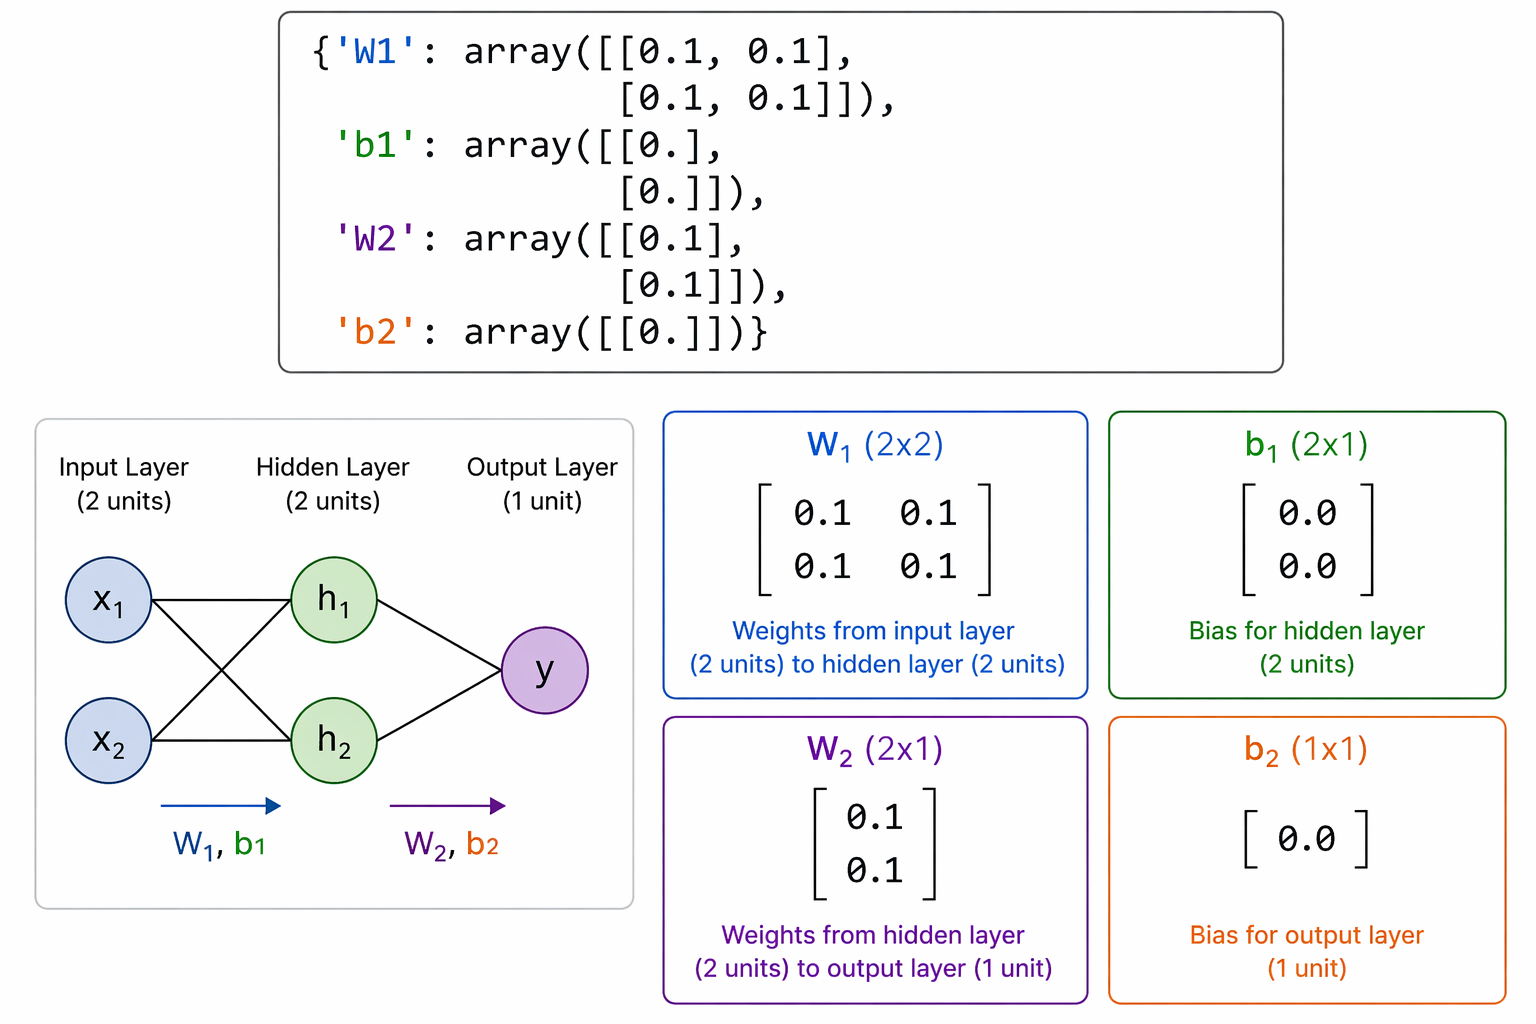

In [17]:
def linear_forward(A_prev, W, b):

  Z = np.dot(W.T, A_prev) + b

  return Z

In [18]:
# Forward Prop
def L_layer_forward(X, parameters):

  A = X
  L = len(parameters) // 2                  # number of layers in the neural network

  for l in range(1, L+1):
    A_prev = A
    Wl = parameters['W' + str(l)]
    bl = parameters['b' + str(l)]
    #print("A"+str(l-1)+": ", A_prev)
    #print("W"+str(l)+": ", Wl)
    #print("b"+str(l)+": ", bl)
    #print("--"*20)

    A = linear_forward(A_prev, Wl, bl)
    #print("A"+str(l)+": ", A)
    #print("**"*20)

  return A,A_prev

In [19]:
X = df[['cgpa', 'profile_score']].values[0].reshape(2,1) # Shape(no of features, no. of training example)
y = df[['lpa']].values[0][0]

# Parameter initialization
parameters = initialize_parameters([2,2,1])

y_hat,A1 = L_layer_forward(X, parameters)

In [20]:
L_layer_forward(X,parameters)

(array([[0.32]]),
 array([[1.6],
        [1.6]]))

In [21]:
X

array([[8],
       [8]])

In [15]:
y

np.int64(4)

In [23]:
(y - 0.32)**2

np.float64(13.5424)

In [12]:
y_hat = y_hat[0][0]

In [13]:
A1

array([[1.6],
       [1.6]])

In [24]:
def update_parameters(parameters,y,y_hat,A1,X):
  parameters['W2'][0][0] = parameters['W2'][0][0] + (0.001 * 2 * (y - y_hat)*A1[0][0])
  parameters['W2'][1][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat)*A1[1][0])
  parameters['b2'][0][0] = parameters['W2'][1][0] + (0.001 * 2 * (y - y_hat))

  parameters['W1'][0][0] = parameters['W1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[0][0])
  parameters['W1'][0][1] = parameters['W1'][0][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0]*X[1][0])
  parameters['b1'][0][0] = parameters['b1'][0][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][0][0])

  parameters['W1'][1][0] = parameters['W1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[0][0])
  parameters['W1'][1][1] = parameters['W1'][1][1] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0]*X[1][0])
  parameters['b1'][1][0] = parameters['b1'][1][0] + (0.001 * 2 * (y - y_hat)*parameters['W2'][1][0])

In [25]:
X = df[['cgpa', 'profile_score']].values[0].reshape(2,1) # Shape(no of features, no. of training example)
y = df[['lpa']].values[0][0]

# Parameter initialization
parameters = initialize_parameters([2,2,1])

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

{'W1': array([[0.10658137, 0.10658137],
        [0.10658137, 0.10658137]]),
 'b1': array([[0.00082267],
        [0.00082267]]),
 'W2': array([[0.111776],
        [0.111776]]),
 'b2': array([[0.119136]])}

In [26]:
X = df[['cgpa', 'profile_score']].values[1].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[1][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

{'W1': array([[0.11458955, 0.1168776 ],
        [0.11458955, 0.1168776 ]]),
 'b1': array([[0.0019667],
        [0.0019667]]),
 'W2': array([[0.12712927],
        [0.12712927]]),
 'b2': array([[0.13612818]])}

In [27]:
X = df[['cgpa', 'profile_score']].values[2].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[2][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

{'W1': array([[0.12409711, 0.13272353],
        [0.12412266, 0.13276611]]),
 'b1': array([[0.00355129],
        [0.00355555]]),
 'W2': array([[0.14692424],
        [0.14731907]]),
 'b2': array([[0.15810417]])}

In [28]:
X = df[['cgpa', 'profile_score']].values[3].reshape(2,1) # Shape(no of features, no. of training exaplme)
y = df[['lpa']].values[3][0]

y_hat,A1 = L_layer_forward(X,parameters)
y_hat = y_hat[0][0]

update_parameters(parameters,y,y_hat,A1,X)

parameters

{'W1': array([[0.13482804, 0.15847776],
        [0.1349909 , 0.15884991]]),
 'b1': array([[0.00569748],
        [0.0057292 ]]),
 'W2': array([[0.17312488],
        [0.17534027]]),
 'b2': array([[0.18773702]])}

In [29]:
# epochs implementation

parameters = initialize_parameters([2,2,1])
epochs = 5

for i in range(epochs):

  Loss = []

  for j in range(df.shape[0]):

    X = df[['cgpa', 'profile_score']].values[j].reshape(2,1) # Shape(no of features, no. of training example)
    y = df[['lpa']].values[j][0]

    # Parameter initialization


    y_hat,A1 = L_layer_forward(X,parameters)
    y_hat = y_hat[0][0]

    update_parameters(parameters,y,y_hat,A1,X)

    Loss.append((y-y_hat)**2)

  print('Epoch - ',i+1,'Loss - ',np.array(Loss).mean())

parameters

Epoch -  1 Loss -  25.321744156025517
Epoch -  2 Loss -  18.320004165722047
Epoch -  3 Loss -  9.473661050729628
Epoch -  4 Loss -  3.2520938634031613
Epoch -  5 Loss -  1.3407132589299962


{'W1': array([[0.26507636, 0.38558861],
        [0.27800387, 0.40980287]]),
 'b1': array([[0.02749056],
        [0.02974394]]),
 'W2': array([[0.41165744],
        [0.48302736]]),
 'b2': array([[0.48646246]])}